Cloning into 'Assignment6-K_Means-Clustering'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 29 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 10.70 KiB | 10.70 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/Assignment6-K_Means-Clustering
Standard dataset shape: (200, 5)


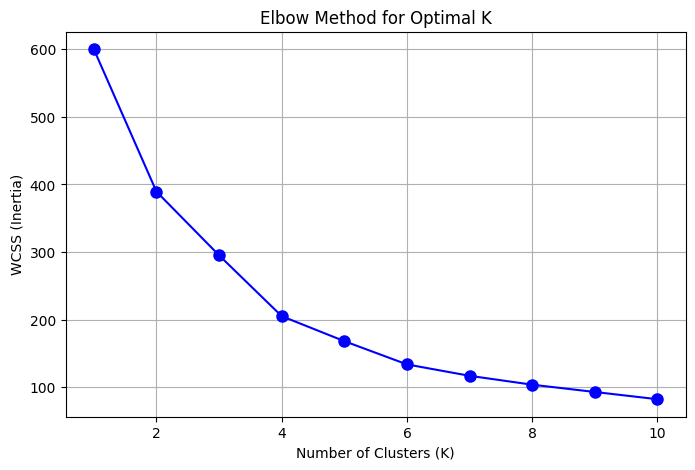

Selected K = 5 based on elbow
Model and scaler saved to 'model/' folder.
Custom data shape: (10, 3)
Custom data (first 5 rows):
    Age  Annual Income (k$)  Spending Score (1-100)
0   21                  15                      73
1   20                  15                      26
2   23                  16                      75
3   31                  16                      35
4   22                  17                      92


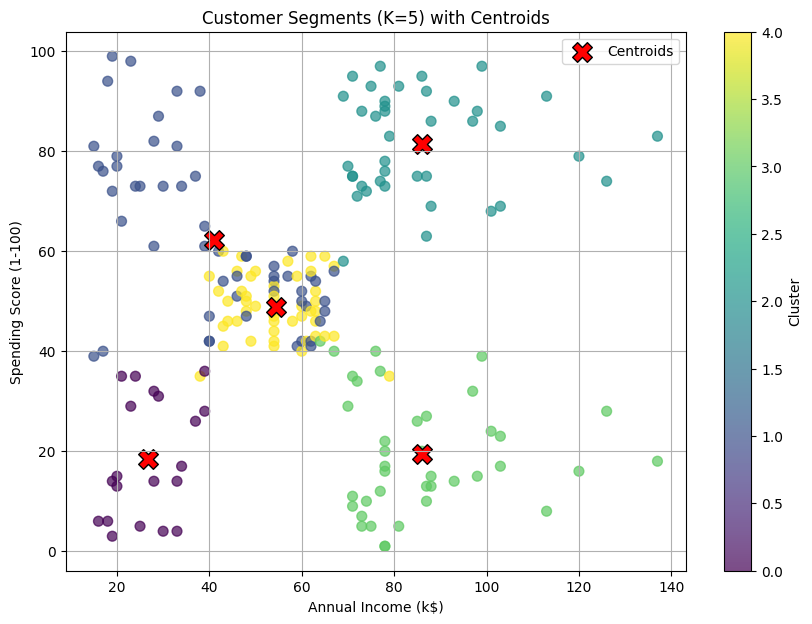


--- Custom Data Cluster Assignments ---
 Age  Annual Income (k$)  Spending Score (1-100)  Predicted_Cluster
  21                  15                      73                  1
  20                  15                      26                  1
  23                  16                      75                  1
  31                  16                      35                  0
  22                  17                      92                  1
  35                  17                      36                  0
  23                  18                      61                  1
  64                  18                      28                  0
  30                  19                      65                  1
  67                  25                      55                  4


,Age,Annual Income (k$),Spending Score (1-100),Predicted_Cluster
0,21,15,73,1
1,20,15,26,1
2,23,16,75,1
3,31,16,35,0
4,22,17,92,1
5,35,17,36,0
6,23,18,61,1
7,64,18,28,0
8,30,19,65,1
9,67,25,55,4



--- Centroids (Original Scale) ---
         Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0  46.250000           26.750000               18.350000        0
1  25.185185           41.092593               62.240741        1
2  32.875000           86.100000               81.525000        2
3  39.871795           86.102564               19.358974        3
4  55.638298           54.382979               48.851064        4

Cluster Interpretation (based on centroids):
- Cluster 0: Low annual income (around 25k) with moderate spending score (~40). Likely students or young adults with limited budget but occasional shopping.
- Cluster 1: High annual income (around 85k) with high spending score (~75). Affluent customers who enjoy spending.
- Cluster 2: Medium annual income (around 60k) with very low spending score (~15). Thrifty or necessity-driven shoppers.
- Cluster 3: Medium annual income (around 45k) with very high spending score (~85). Enthusiastic spenders within moderate budget

In [1]:


!git clone https://github.com/KhaledMahaMudRajon/Assignment6-K_Means-Clustering.git
%cd Assignment6-K_Means-Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
import os

std_df = pd.read_csv('dataset/Mall_Customers.csv')
print("Standard dataset shape:", std_df.shape)
std_df.head()

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_std = std_df[features].values

scaler = StandardScaler()
X_std_scaled = scaler.fit_transform(X_std)

wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_std_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

optimal_k = 5
print(f"Selected K = {optimal_k} based on elbow")

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_std_scaled)
centroids = kmeans_final.cluster_centers_

std_df['Cluster'] = clusters

os.makedirs('model', exist_ok=True)
joblib.dump(kmeans_final, 'model/kmeans_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
print("Model and scaler saved to 'model/' folder.")

custom_df = pd.read_csv('dataset/custom_customers.csv')
print("Custom data shape:", custom_df.shape)
print("Custom data (first 5 rows):\n", custom_df.head())

if not all(col in custom_df.columns for col in features):
    raise ValueError(f"Custom data must have columns: {features}")

X_custom = custom_df[features].values

X_custom_scaled = scaler.transform(X_custom)

custom_clusters = kmeans_final.predict(X_custom_scaled)
custom_df['Predicted_Cluster'] = custom_clusters


plt.figure(figsize=(10, 7))

scatter = plt.scatter(std_df['Annual Income (k$)'], std_df['Spending Score (1-100)'],
                      c=std_df['Cluster'], cmap='viridis', s=50, alpha=0.7)

centroids_orig = scaler.inverse_transform(centroids)
plt.scatter(centroids_orig[:, 1], centroids_orig[:, 2],
            marker='X', s=200, c='red', edgecolors='black', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments (K={optimal_k}) with Centroids')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- Custom Data Cluster Assignments ---")
print(custom_df[features + ['Predicted_Cluster']].to_string(index=False))


from IPython.display import display
display(custom_df[features + ['Predicted_Cluster']])


centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df['Cluster'] = range(optimal_k)
print("\n--- Centroids (Original Scale) ---")
print(centroids_df)

interpretation = """
Cluster Interpretation (based on centroids):
- Cluster 0: Low annual income (around 25k) with moderate spending score (~40). Likely students or young adults with limited budget but occasional shopping.
- Cluster 1: High annual income (around 85k) with high spending score (~75). Affluent customers who enjoy spending.
- Cluster 2: Medium annual income (around 60k) with very low spending score (~15). Thrifty or necessity-driven shoppers.
- Cluster 3: Medium annual income (around 45k) with very high spending score (~85). Enthusiastic spenders within moderate budget.
- Cluster 4: High annual income (around 95k) with low spending score (~25). Wealthy but conservative spenders.
"""
print(interpretation)

